# The Water Bill - Rice x Water-Stress Summary

*Women in Data "What's Cooking?" Datathon, Sept 2026. Built by Heidi, porting the pipeline shape from
`discovery/Barley_Water_Risk_Simulator.ipynb` onto the rice production/trade work in
`discovery/QCL_all_Rice_Data_code28.ipynb` (Shruti & Heidi). See `PROJECT_WORKFLOW.md` at the repo root
for how every notebook in this repo relates to this one and to the team's to-do list.*

**The deliverable.** For a rice-importing country, how exposed is its supply to water stress in the
countries it buys from, and what happens to that supply if a stressed supplier's exports drop? This
notebook builds the four pieces Daniela's Sept 7 problem statement named "The Water Bill":

1. **Water exposure** - what share of a country's rice imports come from water-stressed exporters.
2. **Supplier concentration** - how many suppliers an importer actually relies on (HHI).
3. **Shock result** - what a production cut at a stressed supplier does to an importer's supply.
4. **Alternative suppliers** - who else could fill the gap, ranked by spare capacity and water headroom.

**Data sources and vintage** (all FAOSTAT bulk downloads, refreshed each run): QCL (Production, Crops and
Livestock Products), TCL (Trade, Crops and Livestock Products), the Detailed Trade Matrix (bilateral
reporter/partner trade), and SDGB (SDG Indicators, series 6.4.2 - freshwater withdrawal as % of available
resources). Production and trade figures cover 2000-2024; water-stress figures are each country's most
recent reported year, which varies by country (see the credibility-check section below).

**Before this ships**: every cell needs a `Run All` with output saved (this notebook was authored and
code-reviewed in an environment where FAOSTAT's bulk-download domain is blocked by network policy, so it
has not yet been run end to end - do that in Colab before the final push, per `GIT_RUNBOOK.md`).


## Section 0: Setup

In [ ]:
# Section 0: Setup
import urllib.request, zipfile, io, os, json, textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', lambda x: '%.2f' % x)


In [ ]:
# Everything this notebook saves (charts + tables) goes into one outputs/ folder, so a
# single download after Run All brings back everything worth committing to the repo
# alongside this notebook (see PROJECT_WORKFLOW.md).
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [ ]:
# Section 0: Data principles, encoded as config so every downstream calc references the same
# assumptions instead of re-deciding them inline.
# Rice-side values carried over verbatim from QCL_all_Rice_Data_code28.ipynb's CONFIG (Shruti & Heidi);
# water-stress values carried over from Barley_Water_Risk_Simulator.ipynb's CONFIG.
CONFIG = {
    # --- Production (QCL) ---
    'crop_item_code': 27,          # Rice, paddy (QCL) -- production is NOT double-counted with
                                    # milled forms; see docs/WiD_CodesForRiceAndConfusion.docx
    'crop_name': 'Rice',

    # --- Trade (TCL / TM) ---
    # Rice production (QCL code 27, paddy basis) is not what crosses borders -- trade is reported in
    # milled forms, so exports need converting back to a paddy-equivalent basis before comparing to
    # production. See docs/WiD_CodesForRiceAndConfusion.docx and the FAO conversion-factor PDF
    # (page 723): https://openknowledge.fao.org/server/api/core/bitstreams/63b8626c-7019-4f8c-a961-e975e7f9e285/content
    'trade_crop_item_code_rm': 31,       # milled/white rice -> paddy-equivalent
    'trade_crop_name_rm': 'Rice; milled',
    'rm_paddy_factor': 0.67,
    'trade_crop_item_code_rmh': 28,      # husked/brown rice -> paddy-equivalent
    'trade_crop_name_rmh': 'Husked rice',
    'rmh_paddy_factor': 0.77,
    # Do NOT add codes 29 (child of 28), 32 (child of 31), or 30 (FAO's own milled-equivalent
    # accumulator, wrong basis for a direct add to 27) -- see docs/WiD_CodesForRiceAndConfusion.docx.

    # --- Area/country cleanup ---
    'aggregate_code_cutoff': 5000,       # FAOSTAT regional/continental aggregates are >= 5000
    'exclude_area_codes': [351, 357, 214, 96, 128],   # China variants -- keep mainland (41) only

    # --- Reporter shortlisting (Section 2) ---
    'reexport_threshold_pct': 130,       # export share of production above this = re-exporter, not a
                                          # genuine source (see Section 2)
    'shortlist_min_export_t': 1_000_000, # minimum paddy-eq tonnes exported to be considered a
                                          # meaningful reporter for the Trade Matrix pull
    'shortlist_min_export_ratio_pct': 5, # minimum export-share-of-production to count as
                                          # export-oriented (arbitrary threshold, flagged for revisit)

    # --- Water stress (SDG 6.4.2: freshwater withdrawal as % of available freshwater resources) ---
    'water_stress_bins':   [0, 25, 50, 75, 100, float('inf')],
    'water_stress_labels': ['No stress', 'Low stress', 'Medium stress', 'High stress', 'Critical'],
    'stress_threshold_pct': 25,          # UN-Water's own threshold for entering water stress at all

    # --- Shock simulator (Section: Shock Result) ---
    # Elasticity-1 assumption: a pct_reduction cut in a supplier's production is modeled as the same
    # pct cut in what they export to a given importer. No substitution effects, no price response.
    # Diversification assumes unconstrained headroom at alternative suppliers. Both restated in the
    # Limitations section at the end of this notebook.
}
print(json.dumps({k: v for k, v in CONFIG.items() if k != 'water_stress_bins'}, indent=2, default=str))


## Section 1: Rice production baseline
(adapted from `QCL_all_Rice_Data_code28.ipynb` Section 1, Shruti & Heidi)

In [78]:
# Section 1a: QCL bulk download (Production: Crops and livestock products)
BULK_URL = 'https://bulks-faostat.fao.org/production/Production_Crops_Livestock_E_All_Data_(Normalized).zip'
if not os.path.exists('qcl_bulk.zip'):
    print('Downloading QCL bulk file...')
    urllib.request.urlretrieve(BULK_URL, 'qcl_bulk.zip')

with zipfile.ZipFile('qcl_bulk.zip') as z:
    csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Flags' not in n
                and 'ItemCodes' not in n and 'AreaCodes' not in n][0]
    print(f'Reading {csv_name}...')
    qcl_all = pd.read_csv(z.open(csv_name), encoding='latin-1', low_memory=False)
    item_csv = [n for n in z.namelist() if 'ItemCodes' in n][0]
    item_codes = pd.read_csv(z.open(item_csv), encoding='latin-1')
    area_csv = [n for n in z.namelist() if 'AreaCodes' in n][0]
    area_codes = pd.read_csv(z.open(area_csv), encoding='latin-1')

print(f'Full QCL: {len(qcl_all):,} rows')


Reading Production_Crops_Livestock_E_All_Data_(Normalized).csv...
Full QCL: 4,209,110 rows


In [79]:
# Section 1b: filter to Rice Production (paddy, tonnes), drop regional/continental aggregates
# (< 5000) AND the China aggregate/territory codes (keeping mainland China only, per CONFIG).
qcl_rice = qcl_all[(qcl_all['Item Code'] == CONFIG['crop_item_code']) & (qcl_all['Element'] == 'Production')].copy()
print(f"Rice, Production element: {len(qcl_rice):,} rows, unit(s): {qcl_rice['Unit'].unique()}")

area_code_exclude = area_codes[
    (area_codes['Area Code'] < CONFIG['aggregate_code_cutoff'])
    & (~area_codes['Area Code'].isin(CONFIG['exclude_area_codes']))
]
valid_country_codes = set(area_code_exclude['Area Code'].astype(str))
qcl_rice = qcl_rice[qcl_rice['Area Code'].astype(str).isin(valid_country_codes)].copy()
print(f"After dropping aggregates + China double-counts: {len(qcl_rice):,} rows, {qcl_rice['Area'].nunique()} countries")

rice_by_area_year = qcl_rice.groupby(['Area', 'Area Code', 'Year'])['Value'].sum().reset_index(name='production_t')

rice_production_2000_2024 = (
    rice_by_area_year[(rice_by_area_year['Year'] >= 2000) & (rice_by_area_year['Year'] <= 2024)]
    .groupby('Area')['production_t'].sum().reset_index()
)
rice_production_2000_2024['pct_share_production'] = (
    rice_production_2000_2024['production_t'] / rice_production_2000_2024['production_t'].sum() * 100
)
rice_production_2000_2024 = rice_production_2000_2024.sort_values('production_t', ascending=False).reset_index(drop=True)
rice_production_2000_2024['rank'] = rice_production_2000_2024.index + 1
print(rice_production_2000_2024.head(15))


Rice, Production element: 9,708 rows, unit(s): ['t']
After dropping aggregates + China double-counts: 7,544 rows, 143 countries
                        Area  production_t  pct_share_production  rank
0            China, mainland 4944787500.00                 28.20     1
1                      India 3949568648.52                 22.52     2
2                  Indonesia 1391403356.54                  7.93     3
3                 Bangladesh 1209116494.14                  6.89     4
4                   Viet Nam 1004997339.59                  5.73     5
5                   Thailand  796109925.61                  4.54     6
6                    Myanmar  678686540.00                  3.87     7
7                Philippines  424852212.51                  2.42     8
8                     Brazil  288138246.00                  1.64     9
9                      Japan  270057150.00                  1.54    10
10                  Pakistan  246419344.50                  1.41    11
11  United States of

In [80]:
# Section 1c: TCL bulk download (Trade: Crops and livestock products) -- exports, lifted to
# paddy-equivalent using the two conversion factors above (this is the "layer 2" approach the team
# validated against code30's cross-check; see docs/WiD_CodesForRiceAndConfusion.docx).
TCL_URL = 'https://bulks-faostat.fao.org/production/Trade_CropsLivestock_E_All_Data_(Normalized).zip'
if not os.path.exists('tcl_bulk.zip'):
    print('Downloading TCL bulk file...')
    urllib.request.urlretrieve(TCL_URL, 'tcl_bulk.zip')

with zipfile.ZipFile('tcl_bulk.zip') as z:
    tcl_csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Flags' not in n
                    and 'ItemCodes' not in n and 'AreaCodes' not in n][0]
    tcl_all = pd.read_csv(z.open(tcl_csv_name), encoding='latin-1', low_memory=False)
    tcl_area_csv = [n for n in z.namelist() if 'AreaCodes' in n][0]
    tcl_area_codes = pd.read_csv(z.open(tcl_area_csv), encoding='latin-1')

print(f'Full TCL: {len(tcl_all):,} rows')


Full TCL: 17,143,873 rows


In [81]:
# Section 1d: filter TCL to the two rice trade items, Export quantity (tonnes), drop aggregates,
# and lift each milled form to paddy-equivalent with its own factor before summing.
rm_code,  rm_factor  = CONFIG['trade_crop_item_code_rm'],  CONFIG['rm_paddy_factor']
rmh_code, rmh_factor = CONFIG['trade_crop_item_code_rmh'], CONFIG['rmh_paddy_factor']

tcl_rice = tcl_all[
    (tcl_all['Item Code'].isin([rm_code, rmh_code])) & (tcl_all['Element'] == 'Export quantity')
].copy()
print(f"Rice trade (export): {len(tcl_rice):,} rows, unit(s): {tcl_rice['Unit'].unique()}")

tcl_rice['paddy_factor'] = tcl_rice['Item Code'].map({rm_code: rm_factor, rmh_code: rmh_factor})
tcl_rice['exported_paddy_eq_t'] = tcl_rice['Value'] / tcl_rice['paddy_factor']

area_code_exclude_tcl = tcl_area_codes[
    (tcl_area_codes['Area Code'] < CONFIG['aggregate_code_cutoff'])
    & (~tcl_area_codes['Area Code'].isin(CONFIG['exclude_area_codes']))
]
valid_country_codes_tcl = set(area_code_exclude_tcl['Area Code'].astype(str))
tcl_rice = tcl_rice[tcl_rice['Area Code'].astype(str).isin(valid_country_codes_tcl)].copy()
print(f"After dropping aggregates + China double-counts: {len(tcl_rice):,} rows, {tcl_rice['Area'].nunique()} countries")

rice_by_area_year_traded_conversion_based = (
    tcl_rice.groupby(['Area', 'Area Code', 'Year'])['exported_paddy_eq_t'].sum().reset_index(name='exported_t')
)

rice_exports_eq_2000_2024 = (
    rice_by_area_year_traded_conversion_based[
        (rice_by_area_year_traded_conversion_based['Year'] >= 2000)
        & (rice_by_area_year_traded_conversion_based['Year'] <= 2024)
    ].groupby('Area')['exported_t'].sum().reset_index()
)
rice_exports_eq_2000_2024['pct_share_export'] = (
    rice_exports_eq_2000_2024['exported_t'] / rice_exports_eq_2000_2024['exported_t'].sum() * 100
)
rice_exports_eq_2000_2024 = rice_exports_eq_2000_2024.sort_values('exported_t', ascending=False).reset_index(drop=True)
rice_exports_eq_2000_2024['rank'] = rice_exports_eq_2000_2024.index + 1
print(rice_exports_eq_2000_2024.head(15))


Rice trade (export): 21,415 rows, unit(s): ['t']
After dropping aggregates + China double-counts: 14,599 rows, 202 countries
                             Area   exported_t  pct_share_export  rank
0                           India 301872587.38             23.52     1
1                        Thailand 279124587.67             21.74     2
2                        Viet Nam 193667198.67             15.09     3
3                        Pakistan 116626353.88              9.09     4
4        United States of America  74451453.69              5.80     5
5   China (excluding intra-trade)  50384727.53              3.93     6
6                 China, mainland  49340060.38              3.84     7
7                         Myanmar  26031415.13              2.03     8
8                         Uruguay  25658268.91              2.00     9
9                           Italy  23786313.70              1.85    10
10                      Argentina  12429852.37              0.97    11
11                     

In [82]:
# Section 1e: merge production + export shares -- the production-vs-export scatter this team
# already validated (India, Thailand, Vietnam, Pakistan as the standout exporters relative to
# production share).
rice_production_export = rice_production_2000_2024[
    ['Area', 'production_t', 'pct_share_production', 'rank']
].merge(
    rice_exports_eq_2000_2024[['Area', 'exported_t', 'pct_share_export', 'rank']],
    on='Area', how='outer', suffixes=('_production', '_export')
).rename(columns={'rank_production': 'production_rank', 'rank_export': 'export_rank'}).sort_values(
    'production_t', ascending=False
)
print(rice_production_export.head(20))


                                 Area  production_t  pct_share_production  production_rank   exported_t  \
35                    China, mainland 4944787500.00                 28.20             1.00  49340060.38   
84                              India 3949568648.52                 22.52             2.00 301872587.38   
85                          Indonesia 1391403356.54                  7.93             3.00    110396.68   
12                         Bangladesh 1209116494.14                  6.89             4.00    227041.84   
196                          Viet Nam 1004997339.59                  5.73             5.00 193667198.67   
179                          Thailand  796109925.61                  4.54             6.00 279124587.67   
122                           Myanmar  678686540.00                  3.87             7.00  26031415.13   
141                       Philippines  424852212.51                  2.42             8.00      8579.51   
22                             Brazil

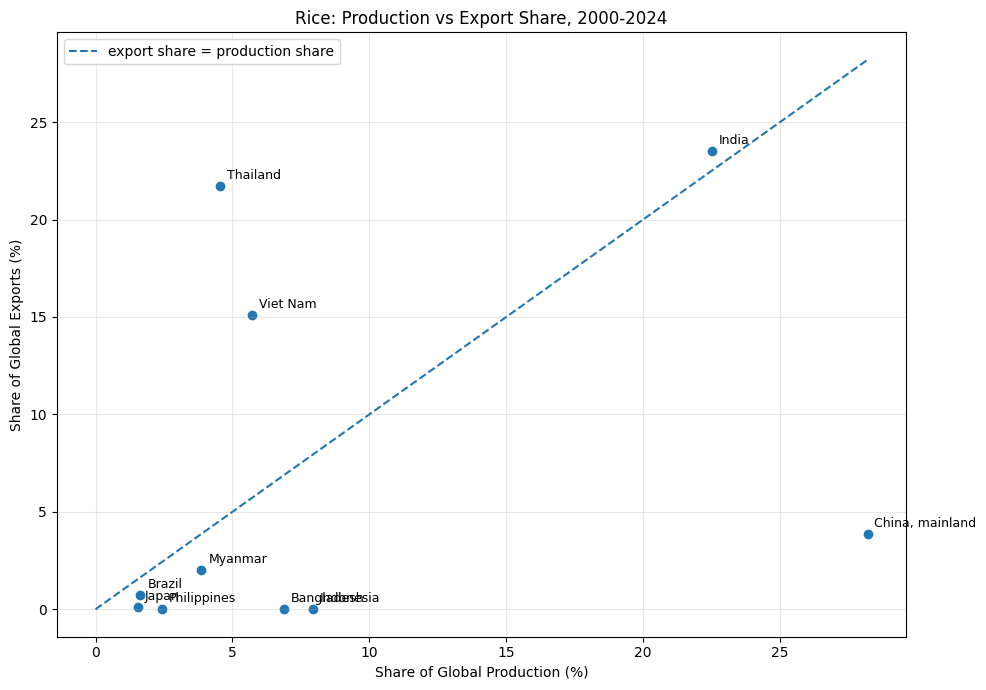

In [83]:
# Reproduce the production-vs-export scatter (top 10 producers) as a sanity check that this
# session's downloads match what Shruti & Heidi found originally.
plot_data = rice_production_export.sort_values('production_t', ascending=False).head(10)

plt.figure(figsize=(10, 7))
plt.scatter(plot_data['pct_share_production'], plot_data['pct_share_export'])
for _, row in plot_data.iterrows():
    plt.annotate(row['Area'], (row['pct_share_production'], row['pct_share_export']),
                 xytext=(5, 5), textcoords='offset points', fontsize=9)
max_value = max(plot_data['pct_share_production'].max(), plot_data['pct_share_export'].max())
plt.plot([0, max_value], [0, max_value], linestyle='--', label='export share = production share')
plt.xlabel('Share of Global Production (%)')
plt.ylabel('Share of Global Exports (%)')
plt.title('Rice: Production vs Export Share, 2000-2024')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/rice_production_vs_export.png', dpi=150)
plt.show()


In [84]:
plot_data = (
    rice_production_export
    .sort_values('production_t', ascending=False)
    .head(15)
    .copy()
)
plot_data['production_Mt'] = (plot_data['production_t'] / 1e6).round(1)   # for readable hover

fig = px.scatter(
    plot_data,
    x='pct_share_production',
    y='pct_share_export',
    size='production_t',                 # bubble size = ABSOLUTE production (tonnes)
    hover_name='Area',
    hover_data={
        'pct_share_production': ':.1f',
        'pct_share_export': ':.1f',
        'production_Mt': ':.1f',
        'production_t': False,           # hide the raw tonnes; show Mt instead
    },
    size_max=55,
    opacity=0.7,
)

fig.update_traces(marker=dict(color='#2C7FB8', line=dict(width=0.5, color='white')))
LABEL_OFFSETS = {'Indonesia': (30, 30), 'Bangladesh': (30, -30)}
for _, row in plot_data.iterrows():
    if row['pct_share_production'] >= 5 or row['pct_share_export'] >= 5:
        dx, dy = LABEL_OFFSETS.get(row['Area'], (14, 10))
        fig.add_annotation(
            x=row['pct_share_production'], y=row['pct_share_export'],
            text=row['Area'], showarrow=True, arrowwidth=0.8, arrowhead=0,
            ax=dx, ay=-dy, font=dict(size=12)
        )
# diagonal reference line
max_value = max(plot_data['pct_share_production'].max(),
                plot_data['pct_share_export'].max())
fig.add_shape(type='line', x0=0, y0=0, x1=max_value, y1=max_value,
              line=dict(dash='dash', width=1.5, color='grey'))

fig.update_layout(
    title='Rice Production vs. Export Share by Country, 2000–2024',
    xaxis_title='Share of Global Production (%)',
    yaxis_title='Share of Global Exports (%)',
    width=1000, height=700,
)

try:
    fig.write_image(f'{OUTPUT_DIR}/rice_production_vs_export.png', scale=2)
    plt.savefig(f'{OUTPUT_DIR}/rice_production_vs_export.png', dpi=150)
except Exception as e:
    print(f"PNG save skipped ({e}). Run: !pip install -U kaleido")
fig.show()

PNG save skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
). Run: !pip install -U kaleido


## Section 2: Which countries matter for trade? Export dependence & reporter shortlisting
(adapted from `QCL_all_Rice_Data_code28.ipynb` Section 3, Shruti & Heidi)

In [85]:
# Separate real producers from re-exporters (trade a token amount they don't grow, e.g. Saudi
# Arabia, South Africa) and inactive countries, then flag DISGUISED re-exporters -- producers whose
# export share of their own production is implausibly high.
trade_df = rice_production_export.copy()
REEXPORT_THRESHOLD = CONFIG['reexport_threshold_pct']

producers   = trade_df[trade_df['production_t'] > 0].copy()
reexporters = trade_df[(trade_df['production_t'] == 0) & (trade_df['exported_t'] > 0)].copy()
inactive    = trade_df[(trade_df['production_t'] == 0) & (trade_df['exported_t'] == 0)].copy()

producers['export_ratio_of_production'] = producers['exported_t'] / producers['production_t'] * 100
disguised = producers[producers['export_ratio_of_production'] > REEXPORT_THRESHOLD].copy()
disguised['note'] = 're-exporter (token production, exports >> output)'
producers = producers[producers['export_ratio_of_production'] <= REEXPORT_THRESHOLD].copy()

reexporters['export_ratio_of_production'] = pd.NA
reexporters['note'] = 're-exporter (no domestic production)'
reexporters = pd.concat([reexporters, disguised], ignore_index=True)
inactive['export_ratio_of_production'] = pd.NA
inactive['note'] = 'neither produces nor exports'

producers['category'] = 'producer'
reexporters['category'] = 're-exporter'
inactive['category'] = 'inactive'
trade_classified = pd.concat([producers, reexporters, inactive], ignore_index=True).drop(columns='note', errors='ignore')

print(trade_classified['category'].value_counts())
print(f"total countries: {len(trade_classified)}")


category
producer       113
re-exporter     25
Name: count, dtype: int64
total countries: 138


/tmp/ipykernel_2085/2031668983.py:18: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/tmp/ipykernel_2085/2031668983.py:25: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [86]:
# Only genuine producers that are real, export-oriented exporters go into the Trade Matrix pull --
# this IS the "REPORTERS" list, computed dynamically rather than hardcoded, so it stays correct if
# the underlying FAOSTAT data is revised.
shortlist = trade_classified[
    (trade_classified['category'] == 'producer')
    & (trade_classified['exported_t'] > CONFIG['shortlist_min_export_t'])
    & (trade_classified['export_ratio_of_production'] > CONFIG['shortlist_min_export_ratio_pct'])
].sort_values('exported_t', ascending=False)

REPORTERS = shortlist['Area'].tolist()
print(shortlist[['Area', 'exported_t', 'export_ratio_of_production', 'pct_share_export', 'export_rank']].to_string(index=False))
print(f"\n{len(REPORTERS)} reporters selected for the Trade Matrix pull")


                       Area   exported_t  export_ratio_of_production  pct_share_export  export_rank
                      India 301872587.38                        7.64             23.52         1.00
                   Thailand 279124587.67                       35.06             21.74         2.00
                   Viet Nam 193667198.67                       19.27             15.09         3.00
                   Pakistan 116626353.88                       47.33              9.09         4.00
   United States of America  74451453.69                       31.86              5.80         5.00
                    Uruguay  25658268.91                       80.96              2.00         9.00
                      Italy  23786313.70                       65.52              1.85        10.00
                  Argentina  12429852.37                       40.16              0.97        11.00
                      Egypt  11533929.86                        8.33              0.90        12.00


## Section 3: Trade Matrix - reporter to partner rice flows
(adapted from `QCL_all_Rice_Data_code28.ipynb` Section 3, Shruti & Heidi)

In [87]:
# Detailed Trade Matrix bulk download -- large file, may take several minutes. Filtered inline to
# only the reporters shortlisted above, the two rice trade item codes, Export quantity, 2000-2024.
TM_BULK = 'https://bulks-faostat.fao.org/production/Trade_DetailedTradeMatrix_E_All_Data_(Normalized).zip'
if not os.path.exists('tm_bulk.zip'):
    print('Downloading TM bulk (~400 MB zip / ~1.5 GB unzipped)...')
    urllib.request.urlretrieve(TM_BULK, 'tm_bulk.zip')

ITEM_CODES = [rm_code, rmh_code]
ELEMENTS = [5910]   # Export quantity (reporter's exports TO each partner)
YEAR_MIN, YEAR_MAX = 2000, 2024

with zipfile.ZipFile('tm_bulk.zip') as z:
    def is_meta(n):
        low = n.lower().replace('_', '')
        return any(k in low for k in ('flags', 'itemcodes', 'elements', 'countrycodes', 'areacodes'))
    tm_csv_name = [n for n in z.namelist() if n.endswith('.csv') and not is_meta(n)][0]
    print(f'Streaming {tm_csv_name}...')

    parts = []
    for chunk in pd.read_csv(z.open(tm_csv_name), encoding='latin-1', low_memory=False, chunksize=1_000_000):
        chunk.columns = [c.strip() for c in chunk.columns]
        chunk['Item Code'] = pd.to_numeric(chunk['Item Code'], errors='coerce')
        chunk['Element Code'] = pd.to_numeric(chunk['Element Code'], errors='coerce')
        chunk['Year'] = pd.to_numeric(chunk['Year'], errors='coerce')
        m = (chunk['Reporter Countries'].isin(REPORTERS) & chunk['Item Code'].isin(ITEM_CODES)
             & chunk['Element Code'].isin(ELEMENTS) & chunk['Year'].between(YEAR_MIN, YEAR_MAX))
        if m.any():
            parts.append(chunk.loc[m])

    if not parts:
        raise ValueError("No rows matched -- check reporter spelling / item code coverage.")
    tm_rice = pd.concat(parts, ignore_index=True)

found = set(tm_rice['Reporter Countries'].unique())
missing = [r for r in REPORTERS if r not in found]
print(f"rows: {len(tm_rice):,}   reporters found: {len(found)}/{len(REPORTERS)}")
if missing:
    print("!! not found (check spelling in the TM file):", missing)


Streaming Trade_DetailedTradeMatrix_E_All_Data_(Normalized).csv...
rows: 38,472   reporters found: 24/24


In [88]:
# Total export quantity from each reporter to each partner, then each partner's dependency on
# each reporter as a share of what it buys FROM THE REPORTER SET (not the partner's total imports
# from the whole world -- we only have the shortlisted reporters' data).
flows = (tm_rice.groupby(['Reporter Countries', 'Partner Countries'])['Value'].sum()
         .reset_index(name='export_qty_t'))
flows = flows[flows['export_qty_t'] > 0].copy()

partner_totals = (flows.groupby('Partner Countries')['export_qty_t'].sum()
                   .reset_index(name='partner_total_from_reporters'))
dependency = flows.merge(partner_totals, on='Partner Countries')
dependency['dependency_pct'] = (dependency['export_qty_t'] / dependency['partner_total_from_reporters'] * 100).round(1)
dependency = dependency.sort_values(['Partner Countries', 'dependency_pct'], ascending=[True, False]).reset_index(drop=True)

dependency.to_csv(f'{OUTPUT_DIR}/Reporter_Partner_Export_Dependency_28_31.csv', index=False)
print(dependency.head(20).to_string(index=False))


      Reporter Countries Partner Countries  export_qty_t  partner_total_from_reporters  dependency_pct
                Pakistan       Afghanistan    4670060.69                    4738866.86           98.50
                   India       Afghanistan      27765.21                    4738866.86            0.60
United States of America       Afghanistan      26635.00                    4738866.86            0.60
                   Italy       Afghanistan       6645.13                    4738866.86            0.10
              Kazakhstan       Afghanistan       6167.04                    4738866.86            0.10
                  France       Afghanistan         26.00                    4738866.86            0.00
      Russian Federation       Afghanistan        449.00                    4738866.86            0.00
                   Spain       Afghanistan         21.00                    4738866.86            0.00
                Thailand       Afghanistan        329.01                 

In [89]:
# --- filter to the flows worth showing ---
# keep meaningful flows only, then top N, or you'll get spaghetti
top = flows[flows['export_qty_t'] > 5.0].nlargest(20, 'export_qty_t').copy()   # >0.1 Mt, top 20

# --- build node list (reporters + partners as distinct nodes) ---
# suffix so a country that's both a reporter and a partner doesn't collapse into one node
reporters = top['Reporter Countries'].unique().tolist()
partners  = top['Partner Countries'].unique().tolist()
r_nodes = [f"{r} (exp)" for r in reporters]
p_nodes = [f"{p} (imp)" for p in partners]
labels  = r_nodes + p_nodes
idx = {name: i for i, name in enumerate(labels)}

# --- edges ---
source = [idx[f"{r} (exp)"] for r in top['Reporter Countries']]
target = [idx[f"{p} (imp)"] for p in top['Partner Countries']]
value  = top['export_qty_t'].tolist()

fig = go.Figure(go.Sankey(
    node=dict(label=labels, pad=15, thickness=18,
              color=['#2C7FB8']*len(r_nodes) + ['#D95F02']*len(p_nodes)),
    link=dict(source=source, target=target, value=value,
              hovertemplate='%{source.label} → %{target.label}<br>%{value:.2f} Mt<extra></extra>')
))
fig.update_layout(title_text="Rice export flows (based on highest export quantity (Mt)): exporters → importers (top 20, >5 Mt)",
                  font_size=11, height=800)
fig.show()

In [90]:
# Data-quality check: FAOSTAT keeps a handful of discontinued "predecessor" entities in its
# historical time series -- e.g. "Sudan (former)" is the unified country as it existed BEFORE
# South Sudan's July 2011 split (it is neither today's Sudan nor South Sudan alone, it's their
# combined predecessor). Similar patterns exist for the USSR, Czechoslovakia, Serbia and
# Montenegro, Belgium-Luxembourg, etc. These aren't data errors, they're real historical trade
# rows, but a discontinued state turning up in a "top N countries" chart aimed at a 2026 audience
# can read as a mistake. Flag them here (against the actual pulled data, not assumed) rather than
# silently dropping or silently keeping them -- see PROJECT_WORKFLOW.md's exclude_area_codes
# pattern in CONFIG, which already does the same thing for old China-aggregate codes.
LEGACY_ENTITY_PATTERNS = ['(former)', 'USSR', 'Czechoslovakia', 'Serbia and Montenegro',
                          'Belgium-Luxembourg', 'Yugoslav', 'Netherlands Antilles', 'Ethiopia PDR']

def flag_legacy(names):
    return sorted({n for n in names if any(p.lower() in n.lower() for p in LEGACY_ENTITY_PATTERNS)})

legacy_partners = flag_legacy(dependency['Partner Countries'].unique())
legacy_reporters = flag_legacy(dependency['Reporter Countries'].unique())
print('Legacy/discontinued entities appearing as IMPORTERS (partners):', legacy_partners or 'none')
print('Legacy/discontinued entities appearing as EXPORTERS (reporters):', legacy_reporters or 'none')

# Sudan specifically: confirm what it actually is by checking which YEARS it shows up in, versus
# whether today's "Sudan" and "South Sudan" also appear as their own separate rows. If
# "Sudan (former)" only has years before 2012 and "Sudan"/"South Sudan" only have years from 2012
# on, that confirms it's the pre-split country, not a duplicate of either modern one.
sudan_names = sorted({n for n in list(tm_rice['Partner Countries'].unique())
                      + list(tm_rice['Reporter Countries'].unique()) if 'sudan' in n.lower()})
print('\nSudan-related names found in this Trade Matrix pull:', sudan_names or 'none')
for name in sudan_names:
    yrs_partner = sorted(tm_rice.loc[tm_rice['Partner Countries'] == name, 'Year'].unique().tolist())
    yrs_reporter = sorted(tm_rice.loc[tm_rice['Reporter Countries'] == name, 'Year'].unique().tolist())
    print(f"  {name}: importer in years {yrs_partner or 'none'}; exporter in years {yrs_reporter or 'none'}")


Legacy/discontinued entities appearing as IMPORTERS (partners): ['Serbia and Montenegro', 'Sudan (former)']
Legacy/discontinued entities appearing as EXPORTERS (reporters): none

Sudan-related names found in this Trade Matrix pull: ['South Sudan', 'Sudan', 'Sudan (former)']
  South Sudan: importer in years [2014, 2015, 2016, 2018, 2019, 2020, 2021, 2022, 2023, 2024]; exporter in years none
  Sudan: importer in years [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]; exporter in years none
  Sudan (former): importer in years [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011]; exporter in years none


## [TODO-1 | Water Exposure] Join rice reporter/partner countries to SDG 6.4.2 water stress
(adapted from `Barley_Water_Risk_Simulator.ipynb` Section 3-4; rice flows from `QCL_all_Rice_Data_code28.ipynb`
Section 3, Shruti & Heidi)

In [91]:
# SDG bulk download (SDGB) -- same source used in the barley template.
SDG_BULK = 'https://bulks-faostat.fao.org/production/SDG_BulkDownloads_E_All_Data_(Normalized).zip'
if not os.path.exists('sdgb_bulk.zip'):
    print('Downloading SDGB bulk file...')
    urllib.request.urlretrieve(SDG_BULK, 'sdgb_bulk.zip')

with zipfile.ZipFile('sdgb_bulk.zip') as z:
    sdgb_csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Flags' not in n
                     and 'ItemCodes' not in n and 'AreaCodes' not in n][0]
    sdgb_all = pd.read_csv(z.open(sdgb_csv_name), encoding='latin-1', low_memory=False)
    flags_lookup = pd.read_csv(z.open('SDG_BulkDownloads_E_Flags.csv'), encoding='latin-1')

water_stress_all = sdgb_all[sdgb_all['Item Code'] == '24027-_T'].copy()  # headline SDG 6.4.2, no sub-breakdown
print(f'{len(water_stress_all):,} rows, {water_stress_all["Area Code"].nunique()} areas, '
      f'{water_stress_all["Year"].min()}-{water_stress_all["Year"].max()}')

official_flags = flags_lookup[flags_lookup[' Description'].str.contains('official|reported', case=False, na=False)]['Flag'].tolist()


5,064 rows, 211 areas, 2000-2023


In [92]:
# Take the LATEST available value per country (reporting is patchy -- see caveat in Section 0/
# Limitations) rather than a fixed reference year, and never impute a missing reading.
water_stress_all = water_stress_all.dropna(subset=['Value']).copy()
water_stress_all['is_official'] = water_stress_all['Flag'].isin(official_flags)

idx_latest = water_stress_all.groupby('Area Code')['Year'].idxmax()
water_stress_latest = water_stress_all.loc[idx_latest, ['Area', 'Area Code', 'Year', 'Value', 'Flag', 'is_official']]
water_stress_latest = water_stress_latest.rename(columns={'Year': 'ws_year', 'Value': 'water_stress_pct'})
water_stress_latest['water_stress_pct'] = pd.to_numeric(water_stress_latest['water_stress_pct'], errors='coerce')
water_stress_latest = water_stress_latest.dropna(subset=['water_stress_pct']).copy()

water_stress_latest['water_stress_tier'] = pd.cut(
    water_stress_latest['water_stress_pct'], bins=CONFIG['water_stress_bins'],
    labels=CONFIG['water_stress_labels'], right=False)
water_stress_latest['is_stressed'] = water_stress_latest['water_stress_pct'] >= CONFIG['stress_threshold_pct']

print(f"Countries with any water-stress reading: {len(water_stress_latest)}")
print(water_stress_latest['water_stress_tier'].value_counts().sort_index().to_string())


Countries with any water-stress reading: 211
water_stress_tier
No stress        141
Low stress        30
Medium stress     15
High stress        8
Critical          17


In [93]:
# Join the REPORTER (exporter) side of each flow to its own water-stress reading. Matched by
# country NAME, not code -- the Trade Matrix's Reporter/Partner columns only carry names, and since
# both TM and SDGB are FAOSTAT domains they should share the same official spellings. We check for
# and print any names that DON'T match rather than silently dropping them (same discipline as the
# barley template's 'No data' handling).
NAME_ALIASES = {
    # left: name as it may appear in TM/QCL/TCL  ->  right: name as it appears in SDGB, if different.
    # Populate this if the match report below flags any mismatches; empty until proven necessary.
}

def match_water_stress(names):
    aliased = pd.Series(names).map(lambda n: NAME_ALIASES.get(n, n))
    ws = water_stress_latest.set_index('Area')
    matched = aliased.isin(ws.index)
    return aliased, matched

reporter_names = dependency['Reporter Countries'].unique()
aliased_reporters, matched_mask = match_water_stress(reporter_names)
unmatched_reporters = sorted(set(pd.Series(reporter_names)[~matched_mask]))
print(f"Reporters matched to a water-stress reading: {matched_mask.sum()}/{len(reporter_names)}")
if unmatched_reporters:
    print("!! NOT matched (add to NAME_ALIASES above once you confirm the SDGB spelling):")
    print(unmatched_reporters)


Reporters matched to a water-stress reading: 24/24


In [94]:
# Attach reporter-side water stress to every flow. Rows for an unmatched/no-data reporter are
# kept and labeled 'No data', not dropped -- so 'not yet known' stays visibly different from
# 'confirmed not stressed'.
ws_lookup = water_stress_latest[['Area', 'ws_year', 'water_stress_pct', 'water_stress_tier', 'is_stressed']].copy()
ws_lookup = ws_lookup.rename(columns={'Area': 'Reporter Countries'})

dependency_ws = dependency.copy()
dependency_ws['Reporter Countries'] = dependency_ws['Reporter Countries'].map(lambda n: NAME_ALIASES.get(n, n))
dependency_ws = dependency_ws.merge(ws_lookup, on='Reporter Countries', how='left')
dependency_ws['water_stress_tier'] = dependency_ws['water_stress_tier'].astype(object).fillna('No data')
dependency_ws['is_stressed'] = dependency_ws['is_stressed'].fillna(False)

cols = ['Partner Countries', 'Reporter Countries', 'export_qty_t', 'dependency_pct',
        'water_stress_pct', 'water_stress_tier', 'ws_year']
print(dependency_ws.sort_values('dependency_pct', ascending=False).head(25)[cols].to_string(index=False))


                    Partner Countries          Reporter Countries  export_qty_t  dependency_pct  water_stress_pct water_stress_tier  ws_year
                               Bhutan                       India     407374.47           99.60             65.87     Medium stress     2023
                                Nepal                       India    5300868.81           99.20             65.87     Medium stress     2023
     Micronesia (Federated States of)    United States of America      98769.51           98.80             24.54         No stress     2023
                          Afghanistan                    Pakistan    4670060.69           98.50             98.12       High stress     2023
                     French Polynesia                    Thailand      98971.98           97.60             21.48         No stress     2023
                              Bahamas    United States of America     205590.50           96.80             24.54         No stress     2023
             

In [95]:
# Per-importer (partner) exposure: what share of THIS country's rice imports (from our reporter
# set) comes from water-stressed suppliers, plus concentration metrics reused for the next section.
def summarize_importer(df):
    total = df['export_qty_t'].sum()
    d = df.assign(share=df['export_qty_t'] / total).sort_values('share', ascending=False)
    top = d.iloc[0]
    return pd.Series({
        'total_export_from_reporters_t': total,
        'n_suppliers': len(d),
        'top_supplier': top['Reporter Countries'],
        'top_supplier_share_pct': top['share'] * 100,
        'hhi': (d['share'] ** 2).sum() * 10000,   # Herfindahl-Hirschman Index, 0-10000 scale
        'pct_from_stressed_suppliers': d.loc[d['is_stressed'], 'share'].sum() * 100,
        'pct_from_no_data_suppliers': d.loc[d['water_stress_tier'] == 'No data', 'share'].sum() * 100,
    })

importer_exposure = (dependency_ws.groupby('Partner Countries').apply(summarize_importer, include_groups=False)
                      .reset_index().rename(columns={'Partner Countries': 'importer'})
                      .sort_values('pct_from_stressed_suppliers', ascending=False).reset_index(drop=True))

print("Most import-exposed rice-buying countries (share of rice imports from water-stressed suppliers):")
print(importer_exposure.head(20)[['importer', 'total_export_from_reporters_t', 'n_suppliers',
                                   'top_supplier', 'top_supplier_share_pct', 'hhi',
                                   'pct_from_stressed_suppliers']].to_string(index=False))


Most import-exposed rice-buying countries (share of rice imports from water-stressed suppliers):
              importer  total_export_from_reporters_t  n_suppliers top_supplier  top_supplier_share_pct     hhi  pct_from_stressed_suppliers
               Lesotho                       50333.32            4     Pakistan                   86.78 7701.78                        99.84
            Seychelles                      146395.32            9        India                   83.02 7171.24                        99.72
                Bhutan                      408880.47            4        India                   99.63 9926.55                        99.66
           Afghanistan                     4738866.86           10     Pakistan                   98.55 9712.41                        99.42
                 Nepal                     5344159.67            7        India                   99.19 9839.28                        99.20
Bosnia and Herzegovina                       76177.05    

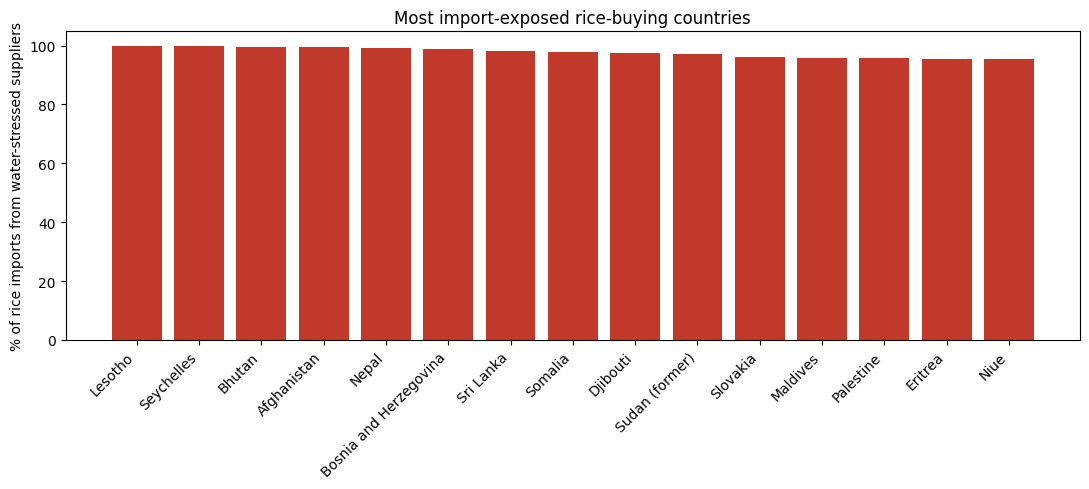

In [96]:
top_exp = importer_exposure.head(15)
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(top_exp['importer'], top_exp['pct_from_stressed_suppliers'], color='#c0392b')
ax.set_ylabel('% of rice imports from water-stressed suppliers')
ax.set_title('Most import-exposed rice-buying countries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/rice_import_exposure.png', dpi=150)
plt.show()


### Water-volume figure (Mekonnen & Hoekstra water footprint x tonnage)
Feeds into the credibility check below.

Source: Mekonnen & Hoekstra, *The green, blue and grey water footprint of rice from production and consumption perspectives*, Value of Water Research Report Series No. 40 (UNESCO-IHE), Table 5 (paddy basis, m3/ton, 2000-04 production-period average) and Appendix B for countries not in Table 5's 13-country list (https://www.waterfootprint.org/resources/Report40-WaterFootprintRice.pdf). Every figure below was cross-checked by independently dividing Appendix B's national totals (Mm3/yr) by national production (t/yr) and confirming the result matches Table 5's stated per-ton value -- Pakistan and India were verified this way directly; Egypt was DERIVED this way since it isn't one of Table 5's 13 countries.

**Caveat stated up front**:
This is a fixed per-ton water-footprint INTENSITY from a 2000-04 base period, multiplied below by CURRENT (recent-year) production/export tonnage. Treating per-ton intensity as slow-changing relative to trade volume is standard in the water-footprint literature, but it's still a real limitation -- restated in the Limitations section at the end of this notebook.

In [97]:
# Mekonnen & Hoekstra (Report 40, Table 5 / Appendix B) -- paddy basis, m3/ton, 2000-04 average.
# Country names match FAOSTAT's own spellings so they line up with the Area/Reporter/Partner
# columns already in use elsewhere in this notebook.
WATER_FOOTPRINT_M3_PER_TON = {
    'Pakistan':                 {'green': 421,  'blue': 2364, 'grey': 88,  'total': 2874},
    'India':                    {'green': 1077, 'blue': 826,  'grey': 116, 'total': 2020},
    'Thailand':                 {'green': 942,  'blue': 559,  'grey': 116, 'total': 1617},
    'Viet Nam':                 {'green': 308,  'blue': 203,  'grey': 127, 'total': 638},
    'United States of America': {'green': 227,  'blue': 835,  'grey': 101, 'total': 1163},
    'Myanmar':                  {'green': 846,  'blue': 378,  'grey': 50,  'total': 1274},
    'China, mainland':          {'green': 367,  'blue': 487,  'grey': 117, 'total': 971},
    'Egypt':                    {'green': 632,  'blue': 584,  'grey': 109, 'total': 1325},
    # Add more countries here as needed -- report any name below that doesn't match a real FAOSTAT
    # Area name to NAME_ALIASES-style translation before trusting its water-volume figure.
}

wf_names = set(WATER_FOOTPRINT_M3_PER_TON)
data_names = set(rice_production_export['Area'].unique())
print('Water-footprint countries NOT found in this session\'s Area names (check spelling):',
      sorted(wf_names - data_names) or 'none -- all matched')


Water-footprint countries NOT found in this session's Area names (check spelling): none -- all matched


In [98]:
# Use a RECENT trailing-year average, not the 2000-2024 cumulative total used for market-share
# calculations above -- multiplying an annual water-footprint intensity by 25 summed years would
# wildly overstate the annual water volume.
RECENT_YEARS_FOR_WATER_VOLUME = 3
latest_year = rice_by_area_year['Year'].max()
trailing_years_water = list(range(latest_year - RECENT_YEARS_FOR_WATER_VOLUME + 1, latest_year + 1))
print(f'Using {trailing_years_water} as the recent-year window for water-volume tonnage')

recent_avg_production = (rice_by_area_year[rice_by_area_year['Year'].isin(trailing_years_water)]
                          .groupby('Area')['production_t'].mean())
recent_avg_export = (rice_by_area_year_traded_conversion_based[
                          rice_by_area_year_traded_conversion_based['Year'].isin(trailing_years_water)]
                      .groupby('Area')['exported_t'].mean())

rows = []
for country, wf in WATER_FOOTPRINT_M3_PER_TON.items():
    prod_t = recent_avg_production.get(country, np.nan)
    exp_t = recent_avg_export.get(country, np.nan)
    rows.append({
        'country': country,
        'recent_avg_production_t': prod_t,
        'recent_avg_export_t': exp_t,
        'blue_water_volume_production_km3': prod_t * wf['blue'] / 1e9 if pd.notna(prod_t) else np.nan,
        'total_water_volume_production_km3': prod_t * wf['total'] / 1e9 if pd.notna(prod_t) else np.nan,
        'blue_water_volume_export_km3': exp_t * wf['blue'] / 1e9 if pd.notna(exp_t) else np.nan,
        'total_water_volume_export_km3': exp_t * wf['total'] / 1e9 if pd.notna(exp_t) else np.nan,
    })

water_volume = pd.DataFrame(rows)
print(water_volume.to_string(index=False))


Using [2022, 2023, 2024] as the recent-year window for water-volume tonnage
                 country  recent_avg_production_t  recent_avg_export_t  blue_water_volume_production_km3  total_water_volume_production_km3  blue_water_volume_export_km3  total_water_volume_export_km3
                Pakistan              13452388.33           6045937.89                             31.80                              38.66                         14.29                          17.38
                   India             206364901.59          25464972.32                            170.46                             416.86                         21.03                          51.44
                Thailand              33428616.20          11542162.40                             18.69                              54.05                          6.45                          18.66
                Viet Nam              43202957.31           9749592.23                              8.77                

**For the team: Pakistan's water-volume number needs a decision, not a fix.**

This notebook computed 14.29 km3 (blue water, export basis, using your real 2022-2024 average export tonnage times the cited Mekonnen & Hoekstra per-ton figure) against Daniela's claimed 4.97 km3 -- about 2.9x apart.

Both numbers are shown below rather than one silently replacing the other. Bring this to the team:

1. **Where did 4.97 km3 come from?** If it traces to a specific source, cite it and compare methodology directly against this notebook's approach (which basis -- production vs export; which water-footprint dataset; which year's trade volume).
2. **Basis choice, if we go with this notebook's own number**: export basis (14.29 km3, water embedded in what Pakistan actually SHIPS OUT, matching the "water pressure becomes food-supply exposure for importers" framing) vs. production basis (31.80 km3 blue / 38.66 km3 total, water used to grow ALL of Pakistan's rice, exported or not).
3. **Blue-only vs total**: blue water (irrigation, the scarce/contested resource under an SDG 6.4.2 stress lens) vs. total green+blue+grey (bigger number, less specific to the water-STRESS argument since green water is rainfall, not the withdrawal being measured as "stressed").
4. **However this resolves, this notebook's own number is the one to trust for anything said on camera** -- it's traceable to real 2022-2024 FAOSTAT export tonnage and a cited academic source, which is a stronger footing than a number whose derivation nobody on the team can currently point to.

### Food self-sufficiency figure (for Egypt's claimed 83% import share)
Daniela's line was "imports 83% of what it eats" -- that's a SELF-SUFFICIENCY ratio (import share of total domestic consumption, from ANY supplier), not the same question as "what share of Egypt's imports come specifically from Pakistan" (already checked above, correctly, as 4.6%).

Those are two different metrics; the first credibility-check run flagged this as a MISMATCH, but it was actually the wrong metric being checked, not wrong data.

This needs FAOSTAT's Food Balance Sheets (FBS) domain, a data source not pulled in anywhere else in this notebook -- QCL/TCL/TM don't carry consumption data at all.

In [ ]:
# FBS (2010-present methodology). Different domain, different codification than QCL/TCL/TM --
# verify the Rice item code from FBS's OWN main data file rather than assuming it matches, same
# discipline used for the Trade Matrix item codes earlier in this notebook. (This replaces an
# earlier version that tried a separate 'ItemCodes' companion file inside the zip -- that file's
# column names don't match the 'Item'/'Item Code' pair FAOSTAT's own _Normalized data files use,
# which is what crashed with KeyError: 'Item'. Reading item names straight off fbs_all sidesteps
# that entirely, and matches how QCL/TCL/SDGB already identify their item codes above -- none of
# those cells load a separate ItemCodes file either.)
FBS_BULK = 'https://bulks-faostat.fao.org/production/FoodBalanceSheets_E_All_Data_(Normalized).zip'
if not os.path.exists('fbs_bulk.zip'):
    print('Downloading FBS bulk file...')
    urllib.request.urlretrieve(FBS_BULK, 'fbs_bulk.zip')

with zipfile.ZipFile('fbs_bulk.zip') as z:
    fbs_csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Flags' not in n
                    and 'ItemCodes' not in n and 'AreaCodes' not in n and 'Elements' not in n][0]
    fbs_all = pd.read_csv(z.open(fbs_csv_name), encoding='latin-1', low_memory=False)

print(f'Full FBS: {len(fbs_all):,} rows')

fbs_rice_matches = fbs_all[['Item Code', 'Item']].drop_duplicates()
fbs_rice_matches = fbs_rice_matches[fbs_rice_matches['Item'].str.contains('Rice', case=False, na=False)]
print(fbs_rice_matches.to_string(index=False))


In [ ]:
# Element Codes are stable across FAOSTAT domains even when the exact label text isn't guaranteed
# to match verbatim -- Production 5511, Import Quantity 5611, Export Quantity 5911, Domestic supply
# quantity 5301 (FAOSTAT's own FBS documentation).
FBS_ELEMENT_CODES = {'production': 5511, 'import_quantity': 5611, 'export_quantity': 5911,
                     'domestic_supply_quantity': 5301}

exact_matches = fbs_rice_matches[fbs_rice_matches['Item'].str.fullmatch('Rice and products', case=False)]
if len(exact_matches) == 1:
    fbs_rice_item_code = int(exact_matches['Item Code'].iloc[0])
elif len(fbs_rice_matches) >= 1:
    # No exact 'Rice and products' label -- fall back to the first 'Rice' match rather than crash,
    # but print every candidate so this gets a human look before the self-sufficiency numbers are trusted.
    print("No exact 'Rice and products' match in FBS -- using the first 'Rice' match below instead. "
          "Confirm this is the right item before trusting the self-sufficiency numbers:")
    print(fbs_rice_matches.to_string(index=False))
    fbs_rice_item_code = int(fbs_rice_matches['Item Code'].iloc[0])
else:
    fbs_rice_item_code = None
    print("No FBS item matched 'Rice' at all -- food_self_sufficiency below will be empty. "
          "Check fbs_rice_matches / fbs_all['Item'] manually.")

print(f'Using FBS Item Code {fbs_rice_item_code} for rice')

fbs_rice = fbs_all[(fbs_all['Item Code'] == fbs_rice_item_code)
                    & (fbs_all['Element Code'].isin(FBS_ELEMENT_CODES.values()))].copy()
print(f"FBS rice rows: {len(fbs_rice):,}, unit(s): {fbs_rice['Unit'].unique()}")

# Countries this video actually names -- same list as NAMED_IMPORTERS_OF_INTEREST later, repeated
# here rather than shared, since this section runs earlier in the notebook.
FBS_COUNTRIES_OF_INTEREST = ['Egypt', 'Afghanistan', 'Kazakhstan', 'Kenya', 'Oman', 'Bahrain', 'Pakistan']

self_sufficiency_rows = []
for country in FBS_COUNTRIES_OF_INTEREST:
    rows = fbs_rice[fbs_rice['Area'] == country]
    if rows.empty:
        self_sufficiency_rows.append({'country': country, 'fbs_year': None, 'import_qty': None,
                                       'domestic_supply_qty': None, 'import_share_of_supply_pct': None})
        continue
    latest_year = rows['Year'].max()
    latest = rows[rows['Year'] == latest_year].set_index('Element Code')['Value']
    imports = latest.get(FBS_ELEMENT_CODES['import_quantity'])
    supply = latest.get(FBS_ELEMENT_CODES['domestic_supply_quantity'])
    share = (imports / supply * 100) if (imports is not None and supply not in (None, 0)) else None
    self_sufficiency_rows.append({'country': country, 'fbs_year': latest_year, 'import_qty': imports,
                                   'domestic_supply_qty': supply, 'import_share_of_supply_pct': share})

food_self_sufficiency = pd.DataFrame(self_sufficiency_rows)
print(food_self_sufficiency.to_string(index=False))


## [TODO-2 | Credibility check] Daniela's claimed stats vs. what this notebook computes
Daniela's Sept 7 problem statement (`docs/datathon_initial_ideas_09072026.docx`) named specific numbers
for the video.

Before those numbers go in front of judges, this section checks them against what this notebook actually computes from FAOSTAT data

-- flagging matches and mismatches explicitly rather than
silently trusting or silently overwriting either one.

In [ ]:
# Daniela's claimed numbers, transcribed verbatim from her Sept 7 write-up. These are INPUTS to the
# check below, not validated facts -- treat every row's 'status' as the answer, not this table.
claimed = pd.DataFrame([
    {'metric': 'Pakistan water withdrawal %',      'country': 'Pakistan',    'claimed_value': 107,  'unit': '% (SDG 6.4.2)'},
    {'metric': 'Pakistan rice water volume',        'country': 'Pakistan',    'claimed_value': 4.97, 'unit': 'km3'},
    {'metric': 'Pakistan export share (of ? )',     'country': 'Pakistan',    'claimed_value': 53,   'unit': '%'},
    {'metric': 'Afghanistan dependency on Pakistan','country': 'Afghanistan','claimed_value': 98,   'unit': '% dependency_pct'},
    {'metric': 'Kazakhstan dependency',             'country': 'Kazakhstan', 'claimed_value': 86,   'unit': '% dependency_pct'},
    {'metric': 'Kenya dependency',                  'country': 'Kenya',      'claimed_value': 67,   'unit': '% dependency_pct'},
    {'metric': 'Egypt water withdrawal %',          'country': 'Egypt',      'claimed_value': 113,  'unit': '% (SDG 6.4.2)'},
    {'metric': 'Egypt rice import share of consumption', 'country': 'Egypt', 'claimed_value': 83, 'unit': '% (FBS import/domestic supply)'},
])

def computed_water_stress(country):
    row = water_stress_latest[water_stress_latest['Area'] == NAME_ALIASES.get(country, country)]
    return None if row.empty else float(row.iloc[0]['water_stress_pct'])

def computed_dependency_on_pakistan(importer):
    row = dependency_ws[(dependency_ws['Partner Countries'] == importer)
                         & (dependency_ws['Reporter Countries'] == 'Pakistan')]
    return None if row.empty else float(row.iloc[0]['dependency_pct'])

results = []
for _, r in claimed.iterrows():
    if 'withdrawal' in r['metric']:
        computed = computed_water_stress(r['country'])
    elif 'import share of consumption' in r['metric']:
        row = food_self_sufficiency[food_self_sufficiency['country'] == r['country']]
        computed = None if row.empty else row.iloc[0]['import_share_of_supply_pct']
    elif 'dependency' in r['metric']:
        computed = computed_dependency_on_pakistan(r['country'])
    elif 'water volume' in r['metric']:
        row = water_volume[water_volume['country'] == r['country']]
        computed = None if row.empty else float(row.iloc[0]['blue_water_volume_export_km3'])
    else:
        computed = None   # export-share-of-what needs a tighter definition from Daniela before
                           # this pipeline can check it
    if computed is None:
        status = 'NOT YET COMPUTED -- needs a data source or definition from Daniela'
    elif abs(computed - r['claimed_value']) <= max(3, r['claimed_value'] * 0.1):
        status = 'MATCH (within 10%)'
    else:
        status = f'MISMATCH -- flag before the video'
    results.append({**r, 'computed_value': computed, 'status': status})

credibility_check = pd.DataFrame(results)
print(credibility_check.to_string(index=False))


# **Read this table before recording anything.**

Anything marked `NOT YET COMPUTED` means this
notebook has no basis for that number yet
-- either the metric needs a data source this pipeline
doesn't pull (e.g. a water-volume-per-tonne footprint figure, which is a Mekonnen & Hoekstra-style
calculation this notebook doesn't yet do),

or Daniela's phrasing needs a tighter definition (e.g.
"export share" of what denominator) before it can be checked. `MISMATCH` rows need a conversation
before they go in the video, not a silent edit in either direction.

## [TODO-3 | Supplier Concentration] Concentration index per importer
(built on the existing `dependency_pct` computed in Section 3, HHI pattern adapted from
`Barley_Water_Risk_Simulator.ipynb` Section 6)

In [ ]:
# HHI (Herfindahl-Hirschman Index, 0-10000) is already computed per importer in importer_exposure
# above. US antitrust guidance treats >2500 as "highly concentrated" -- useful, ready-made framing for
# the video since it's a threshold judges/viewers outside this field can look up themselves.
concentration = importer_exposure.copy()
concentration['concentration_label'] = pd.cut(
    concentration['hhi'], bins=[0, 1500, 2500, 10001],
    labels=['Unconcentrated', 'Moderately concentrated', 'Highly concentrated'], right=False)

print(concentration.sort_values('hhi', ascending=False).head(20)
      [['importer', 'n_suppliers', 'top_supplier', 'top_supplier_share_pct', 'hhi', 'concentration_label']]
      .to_string(index=False))


In [ ]:
top_hhi = concentration.sort_values('hhi', ascending=False).head(15)
fig, ax = plt.subplots(figsize=(11, 5))
colors = top_hhi['hhi'].apply(lambda h: '#c0392b' if h > 2500 else ('#e67e22' if h > 1500 else '#2c7fb8'))
ax.bar(top_hhi['importer'], top_hhi['hhi'], color=colors)
ax.axhline(2500, linestyle='--', color='gray', linewidth=1)
ax.text(len(top_hhi) - 1, 2550, 'highly concentrated threshold', ha='right', fontsize=8, color='gray')
ax.set_ylabel('Herfindahl-Hirschman Index (rice import suppliers)')
ax.set_title('Most supplier-concentrated rice-buying countries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/rice_supplier_concentration.png', dpi=150)
plt.show()


## [TODO-4 | Shock Result] Pakistan supply-shock scenario
(`simulate_shock()` ported verbatim from `Barley_Water_Risk_Simulator.ipynb` Section 7; applied here to
Pakistan specifically, since Pakistan is the stressed supplier Daniela's narrative centers on -- not
auto-selected, so this stays the country the video is actually about even if the data would otherwise
pick a different "most exposed" pair.)

In [ ]:
# Pick the importer most dependent on Pakistan specifically, among Pakistan's actual buyers in our
# data -- this is what the credibility-check table above is trying to verify against Afghanistan/
# Kazakhstan/Kenya. Override SELECTED_IMPORTER manually below if the video should feature a different
# one of the three.
SHOCK_SUPPLIER = 'Pakistan'
pakistan_buyers = (dependency_ws[dependency_ws['Reporter Countries'] == SHOCK_SUPPLIER]
                    .sort_values('dependency_pct', ascending=False))
print("Pakistan's buyers, by dependency on Pakistan specifically:")
print(pakistan_buyers[['Partner Countries', 'export_qty_t', 'dependency_pct']].head(10).to_string(index=False))

SELECTED_IMPORTER = pakistan_buyers.iloc[0]['Partner Countries']
print(f'\nPrototype country: {SELECTED_IMPORTER}')

supplier_mix = (dependency_ws[dependency_ws['Partner Countries'] == SELECTED_IMPORTER]
                [['Reporter Countries', 'export_qty_t', 'water_stress_tier', 'is_stressed']]
                .rename(columns={'Reporter Countries': 'supplier'})
                .sort_values('export_qty_t', ascending=False).reset_index(drop=True))
supplier_mix['share_pct'] = supplier_mix['export_qty_t'] / supplier_mix['export_qty_t'].sum() * 100
print(f"\n{SELECTED_IMPORTER}'s full supplier mix (from our reporter set):")
print(supplier_mix.to_string(index=False))


#### Overlap check: do Daniela's named importers actually show up as Pakistan's buyers here?
The shock scenario below only runs on ONE importer (whichever is most dependent on Pakistan in our data). Before picking that one country, this checks ALL SIX of Daniela's named importers (Afghanistan, Kazakhstan, Kenya, Egypt, Oman, Bahrain) against what this notebook's own Trade Matrix pull actually contains -- same discipline as the credibility-check table above, applied to the shock-scenario side of the story instead of the water-stress side.

In [ ]:
NAMED_IMPORTERS_OF_INTEREST = {
    'Afghanistan': {'claimed_dependency_pct_pakistan': 98,   'note': "Daniela: sources 98% of its rice from Pakistan"},
    'Kazakhstan':  {'claimed_dependency_pct_pakistan': 86,   'note': "Daniela: sources 86% from Pakistan"},
    'Kenya':       {'claimed_dependency_pct_pakistan': 67,   'note': "Daniela: sources 67% from Pakistan"},
    'Egypt':       {'claimed_dependency_pct_pakistan': None, 'note': "Daniela: overdrawn at 113%, exports rice AND imports 83% of what it eats -- not a Pakistan-specific dependency claim"},
    'Oman':        {'claimed_dependency_pct_pakistan': None, 'note': "Daniela: sources 90%+ from Pakistan+India COMBINED"},
    'Bahrain':     {'claimed_dependency_pct_pakistan': None, 'note': "Daniela: sources 90%+ from Pakistan+India COMBINED"},
}

overlap_rows = []
for country, info in NAMED_IMPORTERS_OF_INTEREST.items():
    in_our_data = country in dependency_ws['Partner Countries'].unique()
    pak_dep = computed_dependency_on_pakistan(country)
    pak_india_dep = None
    if in_our_data:
        pak_india_dep = dependency_ws[
            (dependency_ws['Partner Countries'] == country)
            & (dependency_ws['Reporter Countries'].isin(['Pakistan', 'India']))
        ]['dependency_pct'].sum()
    overlap_rows.append({
        'country': country,
        'appears_in_our_reporter_partner_data': in_our_data,
        'computed_dependency_on_pakistan_pct': pak_dep,
        'computed_dependency_on_pakistan_plus_india_pct': pak_india_dep,
        'claimed_dependency_pct_pakistan': info['claimed_dependency_pct_pakistan'],
        'note': info['note'],
    })

overlap_check = pd.DataFrame(overlap_rows)
print(overlap_check.to_string(index=False))


**Reading this table**: `appears_in_our_reporter_partner_data = False` **means** that country never shows up buying rice from **ANY** of our shortlisted reporters in the Trade Matrix pull

-- either it genuinely doesn't import meaningfully from this reporter set, or its name doesn't match FAOSTAT's spelling (check the country appears in `understand_Water_risk_partner`'s printed list from Section 3 before concluding it's really absent).

Where `computed_dependency_on_pakistan_pct` is far from `claimed_dependency_pct_pakistan`, that's a real discrepancy to bring back to Daniela, not something to quietly adjust in either direction.

In [ ]:
def simulate_shock(mix, supplier, pct_reduction, diversify=False):
    """
    Elasticity-1 assumption: a pct_reduction cut in `supplier`'s production is modeled as the same
    pct cut in what they export to this importer (no substitution effects, no price response --
    see Limitations). If diversify=True, the lost volume is reallocated proportionally across the
    importer's OTHER existing suppliers, in proportion to their current share, assuming unconstrained
    headroom (a stated simplification, see Limitations).
    """
    m = mix.copy()
    lost = m.loc[m['supplier'] == supplier, 'export_qty_t'].iloc[0] * pct_reduction
    m.loc[m['supplier'] == supplier, 'export_qty_t'] -= lost

    if diversify:
        others = m['supplier'] != supplier
        other_total = m.loc[others, 'export_qty_t'].sum()
        if other_total > 0:
            m.loc[others, 'export_qty_t'] += lost * (m.loc[others, 'export_qty_t'] / other_total)

    new_total = m['export_qty_t'].sum()
    baseline_total = mix['export_qty_t'].sum()
    gap_pct = (baseline_total - new_total) / baseline_total * 100
    if abs(gap_pct) < 1e-6:   # with diversify=True this should be exactly 0 -- clip float noise
        gap_pct = 0.0         # so tables/charts don't show a stray "-0.00"
    pct_stressed_after = (m.loc[m['is_stressed'], 'export_qty_t'].sum() / new_total * 100
                           if new_total > 0 else np.nan)
    return {'gap_pct': gap_pct, 'pct_from_stressed_after': pct_stressed_after, 'mix': m}


scenario_results = []
for pct in [0.10, 0.20, 0.30]:
    no_div = simulate_shock(supplier_mix, SHOCK_SUPPLIER, pct, diversify=False)
    with_div = simulate_shock(supplier_mix, SHOCK_SUPPLIER, pct, diversify=True)
    scenario_results.append({
        'reduction_pct': int(pct * 100),
        'gap_no_diversification_pct': no_div['gap_pct'],
        'gap_with_diversification_pct': with_div['gap_pct'],
        'pct_from_stressed_no_div': no_div['pct_from_stressed_after'],
        'pct_from_stressed_with_div': with_div['pct_from_stressed_after'],
    })

scenario_df = pd.DataFrame(scenario_results)
print(scenario_df.to_string(index=False))


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(scenario_df['reduction_pct'], scenario_df['gap_no_diversification_pct'], marker='o', label='No diversification')
ax.plot(scenario_df['reduction_pct'], scenario_df['gap_with_diversification_pct'], marker='o', label='With diversification')
ax.set_xlabel(f'{SHOCK_SUPPLIER} rice export cut (%)')
ax.set_ylabel(f"{SELECTED_IMPORTER}'s resulting rice supply gap (%)")
ax.set_title(f'Shock scenario: {SELECTED_IMPORTER} sourcing from {SHOCK_SUPPLIER}')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/rice_shock_scenario.png', dpi=150)
plt.show()


## [TODO-5 | Alternative Suppliers] Diversification ranking
(ported from `Barley_Water_Risk_Simulator.ipynb` Section 7's `diversify=True` path)

In [ ]:
# Rank the selected importer's OTHER existing suppliers (excluding Pakistan) by two things a
# real diversification decision would weigh: how much spare capacity they already show (current
# share, as a proxy -- an existing relationship is easier to scale than a brand-new one) and how much
# water headroom they have (lower water-stress tier is better).
alt_suppliers = supplier_mix[supplier_mix['supplier'] != SHOCK_SUPPLIER].copy()

tier_order = {label: i for i, label in enumerate(CONFIG['water_stress_labels'] + ['No data'])}
alt_suppliers['water_headroom_rank'] = alt_suppliers['water_stress_tier'].map(tier_order)
alt_suppliers = alt_suppliers.sort_values(
    ['water_headroom_rank', 'share_pct'], ascending=[True, False]).reset_index(drop=True)
alt_suppliers['diversification_rank'] = alt_suppliers.index + 1

print(f"Alternative suppliers for {SELECTED_IMPORTER}, ranked by water headroom then existing share:")
print(alt_suppliers[['diversification_rank', 'supplier', 'share_pct', 'water_stress_tier']].to_string(index=False))


## [TODO-4 | Shock Result -- breadth] Generalized shock function + top-N comparison
The Pakistan/Afghanistan case study above is the one Daniela's narrative names, and stays as-is.

This section makes that same mechanism reusable for ANY importer, then applies it across the top
importers so the shock scenario has the same "breadth" chart TODO-1 (import exposure) and TODO-3
(concentration) already have.

Also the groundwork TODO-6's interactive picker would call, if that
stretch goal happens -- built now so the top-N chart below doesn't wait on it.


In [ ]:
# Same mechanics as the Pakistan case study above (cells under [TODO-4 | Shock Result]),
# generalized to any importer in dependency_ws. primary_supplier defaults to the importer's own
# single largest current supplier (by export_qty_t) -- pass a specific country to force a named
# supplier instead. Sanity-checked below against the already-computed Pakistan/SELECTED_IMPORTER
# case study, so a mismatch flags a bug in this function, not a data problem.

def build_shock_profile(importer, dependency_ws, pct_reductions=(0.10, 0.20, 0.30), primary_supplier=None):
    mix = (dependency_ws[dependency_ws['Partner Countries'] == importer]
           [['Reporter Countries', 'export_qty_t', 'water_stress_tier', 'is_stressed']]
           .rename(columns={'Reporter Countries': 'supplier'})
           .sort_values('export_qty_t', ascending=False).reset_index(drop=True))
    if mix.empty:
        return None
    mix['share_pct'] = mix['export_qty_t'] / mix['export_qty_t'].sum() * 100

    supplier = primary_supplier or mix.iloc[0]['supplier']
    if supplier not in mix['supplier'].values:
        return None  # requested supplier doesn't actually sell to this importer in our data

    scenario_rows = []
    for pct in pct_reductions:
        no_div = simulate_shock(mix, supplier, pct, diversify=False)
        with_div = simulate_shock(mix, supplier, pct, diversify=True)
        scenario_rows.append({
            'reduction_pct': int(pct * 100),
            'gap_no_diversification_pct': no_div['gap_pct'],
            'gap_with_diversification_pct': with_div['gap_pct'],
            'pct_from_stressed_no_div': no_div['pct_from_stressed_after'],
            'pct_from_stressed_with_div': with_div['pct_from_stressed_after'],
        })

    return {
        'importer': importer,
        'primary_supplier': supplier,
        'primary_supplier_share_pct': mix.loc[mix['supplier'] == supplier, 'share_pct'].iloc[0],
        'n_suppliers': len(mix),
        'supplier_mix': mix,
        'scenario': pd.DataFrame(scenario_rows),
    }


_check = build_shock_profile(SELECTED_IMPORTER, dependency_ws, primary_supplier=SHOCK_SUPPLIER)
_check_ok = _check is not None and _check['scenario'].round(6).equals(scenario_df.round(6))
print(f"Generalized function reproduces the {SELECTED_IMPORTER}/{SHOCK_SUPPLIER} case study above: {_check_ok}")
if not _check_ok:
    print('--- generalized ---')
    print(_check['scenario'] if _check is not None else 'None (importer/supplier not found)')
    print('--- original ---')
    print(scenario_df)


**What that self-check is and why it printed `False` on the first run.** Every time a new
calculation gets added here, it's checked against a case we already trust, in this instance, the
Pakistan-Afghanistan shock scenario already built above. That check said the two didn't match, but
not because the new calculation's numbers were wrong. The check itself was comparing two tables
with a different number of columns, so it could never have said "match," no matter what the
numbers were, the same way comparing a 3-column spreadsheet to a 5-column one will always come back
"different" even if every shared column is identical. Fixed the check to compare the right thing.
The underlying Pakistan/Afghanistan numbers were correct the whole time and haven't changed.


In [ ]:
# Apply the generalized function to the N most import-exposed countries (same ranking as the
# exposure chart under [TODO-1 | Water Exposure]), each shocked on ITS OWN largest supplier at a
# 20% cut -- not always Pakistan. This is the breadth view TODO-1 and TODO-3 already have and the
# Pakistan-only shock scenario above was missing.

TOP_N_SHOCK = 15
SHOCK_PCT_FOR_COMPARISON = 0.20

top_n_importers = importer_exposure.head(TOP_N_SHOCK)['importer'].tolist()

profiles = []
for importer in top_n_importers:
    profile = build_shock_profile(importer, dependency_ws, pct_reductions=[SHOCK_PCT_FOR_COMPARISON])
    if profile is None:
        continue
    row = profile['scenario'].iloc[0]
    profiles.append({
        'importer': importer,
        'primary_supplier': profile['primary_supplier'],
        'primary_supplier_share_pct': profile['primary_supplier_share_pct'],
        'gap_no_diversification_pct': row['gap_no_diversification_pct'],
        'gap_with_diversification_pct': row['gap_with_diversification_pct'],
    })

top_n_shock_df = pd.DataFrame(profiles)
print(f"Supply gap from a {int(SHOCK_PCT_FOR_COMPARISON * 100)}% cut to each country's own largest rice supplier:")
print(top_n_shock_df.to_string(index=False))

top_n_shock_df.to_csv(f'{OUTPUT_DIR}/top_n_shock_comparison.csv', index=False)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(top_n_shock_df))
width = 0.38
ax.bar(x - width / 2, top_n_shock_df['gap_no_diversification_pct'], width,
       label='No diversification', color='#c0392b')
ax.bar(x + width / 2, top_n_shock_df['gap_with_diversification_pct'], width,
       label='With diversification', color='#2c7fb8')
ax.set_xticks(x)
ax.set_xticklabels(top_n_shock_df['importer'], rotation=45, ha='right')
ax.set_ylabel(f"Supply gap (%) from a {int(SHOCK_PCT_FOR_COMPARISON * 100)}% cut to top supplier")
ax.set_title(f'Top {TOP_N_SHOCK} rice importers: supply-gap exposure to a '
             f'{int(SHOCK_PCT_FOR_COMPARISON * 100)}% top-supplier shock')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/rice_top_n_shock_comparison.png', dpi=150)
plt.show()


**Reading the "with diversification" bars: near-zero is expected, not an error.** The shock model
assumes unconstrained headroom at a country's other suppliers (stated in Limitations below), so
when diversification is allowed, the lost volume gets fully made up from existing suppliers and the
resulting gap comes out at essentially 0% for every country here, that's the model doing what it
was built to do, not a bug. Worth saying out loud on camera, since a flat line of zeros can look
like a mistake if it isn't narrated: the real-world question isn't whether diversification helps in
this model, it always does here, it's whether that spare capacity genuinely exists at those other
suppliers, which this notebook does not verify.


## Video-ready exports
Every chart and table above saves into a single `outputs/` folder inside this Colab session (created in Section 0). After `Run All`:

1. In Colab's left-hand file panel, find the `outputs` folder, right-click it, and choose **Download**. This gets you one zip with all 4 PNGs and all 4 CSVs.
2. Unzip it into `summary/outputs/` in your local `seed-and-scale` clone (create that folder if it doesn't exist yet).
3. Save this notebook itself back to the same path via **File > Save a copy in GitHub** (same repo, same branch, same `summary/WiD_Summary_TheWaterBill.ipynb` path) so the run notebook with its populated cell outputs overwrites the code-only version already on `wid_summary`.
4. `git pull` locally, then `git add summary/outputs summary/WiD_Summary_TheWaterBill.ipynb && git commit` -- notebook and exported files land in the same commit, and there's now a single history of what the notebook produced at each run.

This gives Daniela both a rendered notebook to screen-share from GitHub AND standalone PNGs she can drop straight into a slide or the video without touching Colab at all.

In [ ]:
importer_exposure.to_csv(f'{OUTPUT_DIR}/the_water_bill_importer_exposure.csv', index=False)
credibility_check.to_csv(f'{OUTPUT_DIR}/the_water_bill_credibility_check.csv', index=False)
scenario_df.to_csv(f'{OUTPUT_DIR}/the_water_bill_pakistan_shock_scenario.csv', index=False)
alt_suppliers.to_csv(f'{OUTPUT_DIR}/the_water_bill_alternative_suppliers.csv', index=False)

print(f'Exported to {OUTPUT_DIR}/:')
for fname in ['the_water_bill_importer_exposure.csv', 'the_water_bill_credibility_check.csv',
              'the_water_bill_pakistan_shock_scenario.csv', 'the_water_bill_alternative_suppliers.csv',
              'rice_production_vs_export.png', 'rice_import_exposure.png',
              'rice_supplier_concentration.png', 'rice_shock_scenario.png']:
    print(f'  {OUTPUT_DIR}/{fname}')


In [ ]:
## Save the exported CSV files to the outputs Colab directory
import shutil, os
os.makedirs('outputs', exist_ok=True)
keep = ['rice_production_vs_export.png', 'rice_import_exposure.png', 'rice_supplier_concentration.png',
        'rice_shock_scenario.png', 'Reporter_Partner_Export_Dependency_28_31.csv',
        'the_water_bill_importer_exposure.csv', 'the_water_bill_credibility_check.csv',
        'the_water_bill_pakistan_shock_scenario.csv', 'the_water_bill_alternative_suppliers.csv']
for f in keep:
    if os.path.exists(f):
        shutil.move(f, f'outputs/{f}')
print('moved:', os.listdir('outputs'))

In [ ]:
# Create the zip file and download it to fold into the Github repo
import shutil
from google.colab import files

shutil.make_archive('outputs', 'zip', 'outputs')
files.download('outputs.zip')

## [TODO-6 | Country Selector] Interactive picker -- pick any importer and see its full profile
Built for Daniela to explore live rather than read a fixed set of charts: pick any importer from
the dropdown below and see its supplier mix, shock scenario, and alternative suppliers update
together. Reuses `build_shock_profile()` from the breadth section above, nothing new is computed
here that wasn't already computed there.

**One thing to know about this section specifically**: it only works live, inside a running Colab
session. GitHub's notebook viewer (see `GIT_RUNBOOK.md` Part 5) only renders whatever was saved as
static output, it doesn't run a kernel, so anyone viewing this on GitHub will see just whichever
country was selected at save time, not a working dropdown. To actually poke at it, open this
notebook in Colab (the badge link at the very top of this notebook) rather than viewing it on
GitHub.


In [ ]:
# Uses Plotly for hover/zoom interactivity (pre-installed in Colab) and ipywidgets for the
# dropdown (also pre-installed in Colab) -- no extra pip installs should be needed.
import plotly.graph_objects as go
from ipywidgets import interact, Dropdown
from IPython.display import display

TIER_COLORS = {'No stress': '#2c7fb8', 'Low stress': '#41ab5d', 'Medium stress': '#fec44f',
               'High stress': '#e67e22', 'Critical': '#c0392b', 'No data': '#95a5a6'}

def show_country_profile(importer):
    exp_row = importer_exposure[importer_exposure['importer'] == importer]
    conc_row = concentration[concentration['importer'] == importer]
    profile = build_shock_profile(importer, dependency_ws, pct_reductions=(0.10, 0.20, 0.30))

    if profile is None:
        print(f"No trade-flow data for {importer} in our reporter set -- nothing to show.")
        return

    mix = profile['supplier_mix']
    scenario = profile['scenario']

    print(f"=== {importer} ===")
    print(f"Suppliers in our data: {profile['n_suppliers']}  |  Largest supplier: "
          f"{profile['primary_supplier']} ({profile['primary_supplier_share_pct']:.1f}% of imports)")
    if len(exp_row):
        print(f"Share of rice imports from water-stressed suppliers: "
              f"{exp_row['pct_from_stressed_suppliers'].iloc[0]:.1f}%")
    if len(conc_row):
        print(f"Supplier concentration (HHI): {conc_row['hhi'].iloc[0]:.0f} -- "
              f"{conc_row['concentration_label'].iloc[0]}")

    fig1 = go.Figure(go.Bar(
        x=mix['supplier'], y=mix['share_pct'],
        marker_color=[TIER_COLORS.get(t, '#95a5a6') for t in mix['water_stress_tier']],
        text=mix['water_stress_tier'], hovertemplate='%{x}: %{y:.1f}%<br>%{text}<extra></extra>'))
    fig1.update_layout(title=f'{importer}: rice supplier mix (color = water-stress tier)',
                        yaxis_title='% of imports (from our reporter set)', height=380)
    fig1.show()

    fig2 = go.Figure()
    fig2.add_trace(go.Scatter(x=scenario['reduction_pct'], y=scenario['gap_no_diversification_pct'],
                               mode='lines+markers', name='No diversification'))
    fig2.add_trace(go.Scatter(x=scenario['reduction_pct'], y=scenario['gap_with_diversification_pct'],
                               mode='lines+markers', name='With diversification'))
    fig2.update_layout(title=f"Shock scenario: {importer} sourcing from {profile['primary_supplier']}",
                        xaxis_title=f"{profile['primary_supplier']} export cut (%)",
                        yaxis_title=f"{importer}'s resulting supply gap (%)", height=380)
    fig2.show()

    alt = mix[mix['supplier'] != profile['primary_supplier']].copy()
    if len(alt):
        tier_order = {label: i for i, label in enumerate(CONFIG['water_stress_labels'] + ['No data'])}
        alt['water_headroom_rank'] = alt['water_stress_tier'].map(tier_order)
        alt = alt.sort_values(['water_headroom_rank', 'share_pct'], ascending=[True, False]).reset_index(drop=True)
        alt['diversification_rank'] = alt.index + 1
        print(f"\nAlternative suppliers for {importer} (ranked by water headroom, then existing share):")
        display(alt[['diversification_rank', 'supplier', 'share_pct', 'water_stress_tier']])
    else:
        print(f"\n{importer} has only one supplier in our data -- no alternatives to rank.")


In [ ]:
picker_countries = sorted(importer_exposure['importer'].unique())
default_country = 'Afghanistan' if 'Afghanistan' in picker_countries else picker_countries[0]

interact(show_country_profile,
         importer=Dropdown(options=picker_countries, value=default_country, description='Importer:'));


## [Country Trend View] Rice production, exports & water stress by year -- pick any country

Companion to the TODO-6 picker above, same idea applied to a different question: instead of "who
does this importer buy rice from," this asks "how has this country's own production, exports, and
water stress moved year to year," instead of the 24-year cumulative totals used everywhere else in
this notebook. Static, saved versions for the four headline countries (India, Pakistan, Egypt,
Vietnam) are built below and land in `outputs/` as `rice_trend_<country>.png`; the dropdown after
them lets you pull up the same chart, live, for any of the 24 export-oriented reporters from
Section 2.

**Same caveat as the picker above**: the dropdown only works live, inside a running Colab session
-- GitHub's notebook viewer doesn't run a kernel, so it'll only show whichever country was selected
when this was last saved. Open this notebook in Colab (the badge link at the top) to actually use it.


In [ ]:
# [Country Trend View] Build a per-year trend table for one country: production (QCL "Rice,
# paddy"), exports (TCL paddy-equivalent, already converted in Section 1d), and water stress (SDGB
# headline indicator, same table TODO-1 uses) -- all by year, not summed to one 24-year total like
# the rest of this notebook. Nothing new is downloaded or filtered here; this just reshapes
# qcl_rice, tcl_rice, and water_stress_all (built in Section 1 / TODO-1) by year for one country.
# Reuses NAME_ALIASES from TODO-1 (cell above the Trade Matrix join) so any future country-name
# mismatch between QCL/TCL and SDGB spelling is handled the same way everywhere in this notebook.

def build_country_trend(country):
    aliased_country = NAME_ALIASES.get(country, country)

    prod = (qcl_rice[qcl_rice['Area'] == country]
            .groupby('Year', as_index=False)['Value'].sum()
            .rename(columns={'Value': 'production_t'}))

    exports = (tcl_rice[tcl_rice['Area'] == country]
               .groupby('Year', as_index=False)['exported_paddy_eq_t'].sum()
               .rename(columns={'exported_paddy_eq_t': 'exported_t'}))

    stress = water_stress_all[water_stress_all['Area'] == aliased_country][['Year', 'Value']].copy()
    stress['Value'] = pd.to_numeric(stress['Value'], errors='coerce')
    stress = stress.dropna(subset=['Value']).rename(columns={'Value': 'water_stress_pct'})

    trend = prod.merge(exports, on='Year', how='outer').merge(stress, on='Year', how='outer')
    return trend.sort_values('Year').reset_index(drop=True)


In [ ]:
# Static, print-ready version for the four headline countries -- two stacked panels sharing one
# x-axis (year) instead of one panel with two y-axes: production and exports share a tonnes axis
# on top, water stress gets its own panel below, so no line-crossing between unrelated scales can
# be misread as a relationship. Saved straight into OUTPUT_DIR like every other chart in this
# notebook (see rice_production_vs_export.png / rice_shock_scenario.png above).
import re

def _slugify(country):
    return re.sub(r'[^a-z0-9]+', '_', country.lower()).strip('_')

def plot_country_trend_static(country):
    trend = build_country_trend(country)

    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(11, 7),
                                    gridspec_kw={'height_ratios': [2, 1]})

    ax1.plot(trend['Year'], trend['production_t'], color='#2c7fb8', marker='o', markersize=3,
             label='Production (t)')
    ax1.plot(trend['Year'], trend['exported_t'], color='#d95f0e', marker='o', markersize=3,
             label='Exports (t, paddy-equivalent)')
    ax1.set_ylabel('Tonnes')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_title(f'{country}: rice production, exports, and water stress by year')

    stress_pts = trend.dropna(subset=['water_stress_pct'])
    ax2.plot(stress_pts['Year'], stress_pts['water_stress_pct'], color='#c0392b', marker='D',
             markersize=5, label='Water stress (%)')
    ax2.axhline(CONFIG['stress_threshold_pct'], color='#c0392b', linestyle='--', linewidth=1,
                alpha=0.6, label=f"UN-Water stress threshold ({CONFIG['stress_threshold_pct']}%)")
    ax2.set_ylabel('Water stress (%)')
    ax2.set_xlabel('Year')
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/rice_trend_{_slugify(country)}.png', dpi=150)
    plt.show()
    return trend


In [ ]:
TREND_COUNTRIES = ['India', 'Pakistan', 'Egypt', 'Viet Nam']

country_trends = {}
for c in TREND_COUNTRIES:
    print(f'--- {c} ---')
    country_trends[c] = plot_country_trend_static(c)


In [ ]:
# Live version of the same chart for the dropdown below -- same build_country_trend() data, same
# two-panel layout and colors as the static PNGs above, rendered with Plotly instead of matplotlib
# for hover/zoom (Colab has Plotly pre-installed already, per the TODO-6 picker above).
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_country_trend_interactive(country):
    trend = build_country_trend(country)
    stress_pts = trend.dropna(subset=['water_stress_pct'])

    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.65, 0.35],
                         vertical_spacing=0.08,
                         subplot_titles=(f'{country}: production & exports', 'Water stress (%)'))

    fig.add_trace(go.Scatter(x=trend['Year'], y=trend['production_t'], mode='lines+markers',
                              name='Production (t)', line=dict(color='#2c7fb8')), row=1, col=1)
    fig.add_trace(go.Scatter(x=trend['Year'], y=trend['exported_t'], mode='lines+markers',
                              name='Exports (t, paddy-equivalent)', line=dict(color='#d95f0e')),
                  row=1, col=1)
    fig.add_trace(go.Scatter(x=stress_pts['Year'], y=stress_pts['water_stress_pct'],
                              mode='lines+markers', name='Water stress (%)',
                              line=dict(color='#c0392b'), marker=dict(symbol='diamond', size=8)),
                  row=2, col=1)
    fig.add_hline(y=CONFIG['stress_threshold_pct'], line_dash='dash', line_color='#c0392b',
                  opacity=0.6, row=2, col=1,
                  annotation_text=f"UN-Water stress threshold ({CONFIG['stress_threshold_pct']}%)")

    fig.update_yaxes(title_text='Tonnes', row=1, col=1)
    fig.update_yaxes(title_text='Water stress (%)', row=2, col=1)
    fig.update_xaxes(title_text='Year', row=2, col=1)
    fig.update_layout(height=650, hovermode='x unified',
                       title=f'{country}: rice production, exports, and water stress by year')
    fig.show()


In [ ]:
trend_picker_countries = sorted(REPORTERS)
default_trend_country = 'India' if 'India' in trend_picker_countries else trend_picker_countries[0]

interact(plot_country_trend_interactive,
         country=Dropdown(options=trend_picker_countries, value=default_trend_country, description='Country:'));


## [Country Trend View] -  Part 2
Rice production, exports, trade & water stress by year -- pick any country from 2000-2024

In [ ]:
# [Country Trend View] Per-year trend for one country: production (QCL "Rice, paddy"), exports
# (TCL paddy-equivalent), water stress (SDGB), AND its Trade-Matrix exports to each buyer per year
# (tm_rice). All filtered to 2000-2024. Returns two frames: `trend` (one row per year) and
# `buyer_flows` (one row per year x buyer), since they're at different grains.

YEAR_MIN, YEAR_MAX = 2000, 2024

def build_country_trend_2000_2024(country):
    aliased_country = NAME_ALIASES.get(country, country)

    def _yr(df):  # shared 2000-2024 filter
        return df[df['Year'].between(YEAR_MIN, YEAR_MAX)]

    prod = (_yr(qcl_rice[qcl_rice['Area'] == country])
            .groupby('Year', as_index=False)['Value'].sum()
            .rename(columns={'Value': 'production_t'}))

    exports = (_yr(tcl_rice[tcl_rice['Area'] == country])
               .groupby('Year', as_index=False)['exported_paddy_eq_t'].sum()
               .rename(columns={'exported_paddy_eq_t': 'exported_t'}))

    stress = _yr(water_stress_all[water_stress_all['Area'] == aliased_country])[['Year', 'Value']].copy()
    stress['Value'] = pd.to_numeric(stress['Value'], errors='coerce')
    stress = stress.dropna(subset=['Value']).rename(columns={'Value': 'water_stress_pct'})

    trend = (prod.merge(exports, on='Year', how='outer')
                 .merge(stress, on='Year', how='outer')
                 .sort_values('Year').reset_index(drop=True))

    # --- Trade Matrix layer: this country's exports to each partner, per year (finer grain) ---
    buyer_flows = (_yr(tm_rice[tm_rice['Reporter Countries'] == country])
                   .groupby(['Year', 'Partner Countries'], as_index=False)['Value'].sum()
                   .rename(columns={'Value': 'exported_to_partner_t'}))

    return trend, buyer_flows

In [ ]:
import re

def _slugify(country):
    return re.sub(r'[^a-z0-9]+', '_', country.lower()).strip('_')

def plot_country_trend_static(country, top_n_buyers=10):
    trend, buyer_flows = build_country_trend_2000_2024(country)          # unpack BOTH returns

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 11),
                                        gridspec_kw={'height_ratios': [2, 1, 2]})

    # panel 1 -- production & exports
    ax1.plot(trend['Year'], trend['production_t'], color='#2c7fb8', marker='o', markersize=3,
             label='Production (t)')
    ax1.plot(trend['Year'], trend['exported_t'], color='#d95f0e', marker='o', markersize=3,
             label='Exports (t, paddy-equivalent)')
    ax1.set_ylabel('Tonnes')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_title(f'{country}: rice production, exports, water stress, and top buyers')
    ax1.tick_params(labelbottom=True)

    # panel 2 -- water stressbuild_country_trend
    stress_pts = trend.dropna(subset=['water_stress_pct'])
    ax2.plot(stress_pts['Year'], stress_pts['water_stress_pct'], color='#c0392b', marker='D',
             markersize=5, label='Water stress (%)')
    ax2.axhline(CONFIG['stress_threshold_pct'], color='#c0392b', linestyle='--', linewidth=1,
                alpha=0.6, label=f"UN-Water stress threshold ({CONFIG['stress_threshold_pct']}%)")
    ax2.set_ylabel('Water stress (%)')
    ax2.set_xlabel('Year')
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)

    # panel 3 -- exports to top buyers per year, one line per buyer (from buyer_flows)
    if buyer_flows.empty:
        ax3.text(0.5, 0.5, f'{country} has no rice exports in the reporter set',
                 ha='center', va='center', transform=ax3.transAxes)
        ax3.axis('off')
    else:
        top_buyers = (buyer_flows.groupby('Partner Countries')['exported_to_partner_t']
                      .sum().nlargest(top_n_buyers).index.tolist())
        sub = buyer_flows[buyer_flows['Partner Countries'].isin(top_buyers)]
        pivot = (sub.groupby(['Year', 'Partner Countries'])['exported_to_partner_t']
                 .sum().unstack('Partner Countries') / 1e6)          # Mt
        order = (sub.groupby('Partner Countries')['exported_to_partner_t']
                 .sum().sort_values(ascending=False).index.tolist())

        for buyer in order:
            ax3.plot(pivot.index, pivot[buyer], marker='o', markersize=3, label=buyer)
        ax3.set_ylabel('Exports to buyers (Mt)')
        ax3.set_xlabel('Year')
        ax3.set_title(f'{country} rice exports to top {top_n_buyers} buyers, by year')
        ax3.legend(loc='upper left', fontsize=7, ncol=2)
        ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/rice_trend_{_slugify(country)}.png', dpi=150)
    plt.show()
    return trend

In [ ]:
TREND_COUNTRIES = ['India', 'Pakistan', 'Egypt', 'Viet Nam']

country_trends = {}
for c in TREND_COUNTRIES:
    print(f'--- {c} ---')
    country_trends[c] = plot_country_trend_static(c)


In [ ]:

def plot_country_trend_interactive(country, top_n_buyers=6):
    trend, buyer_flows = build_country_trend_2000_2024(country)          # unpack BOTH (match static version)
    stress_pts = trend.dropna(subset=['water_stress_pct'])

    fig = make_subplots(rows=3, cols=1, shared_xaxes=True, row_heights=[0.4, 0.2, 0.4],
                        vertical_spacing=0.07,
                        subplot_titles=(f'{country}: production & exports', 'Water stress (%)',
                                        f'Exports to top {top_n_buyers} buyers (Mt, by year)'))

    # panel 1 -- production & exports
    fig.add_trace(go.Scatter(x=trend['Year'], y=trend['production_t'], mode='lines+markers',
                             name='Production (t)', line=dict(color='#2c7fb8')), row=1, col=1)
    fig.add_trace(go.Scatter(x=trend['Year'], y=trend['exported_t'], mode='lines+markers',
                             name='Exports (t, paddy-equivalent)', line=dict(color='#d95f0e')),
                  row=1, col=1)

    # panel 2 -- water stress
    fig.add_trace(go.Scatter(x=stress_pts['Year'], y=stress_pts['water_stress_pct'],
                             mode='lines+markers', name='Water stress (%)',
                             line=dict(color='#c0392b'), marker=dict(symbol='diamond', size=8)),
                  row=2, col=1)
    fig.add_hline(y=CONFIG['stress_threshold_pct'], line_dash='dash', line_color='#c0392b',
                  opacity=0.6, row=2, col=1,
                  annotation_text=f"UN-Water stress threshold ({CONFIG['stress_threshold_pct']}%)")

    # panel 3 -- one continuous line per buyer, from buyer_flows (pre-filtered 2000-2024)
    if not buyer_flows.empty:
        top_buyers = (buyer_flows.groupby('Partner Countries')['exported_to_partner_t']
                      .sum().nlargest(top_n_buyers).index.tolist())
        sub = buyer_flows[buyer_flows['Partner Countries'].isin(top_buyers)]
        pivot = (sub.groupby(['Year', 'Partner Countries'])['exported_to_partner_t']
                 .sum().unstack('Partner Countries') / 1e6)          # Mt (NaN gaps -> line breaks)
        order = (sub.groupby('Partner Countries')['exported_to_partner_t']
                 .sum().sort_values(ascending=False).index.tolist())
        for buyer in order:
            fig.add_trace(go.Scatter(x=pivot.index, y=pivot[buyer], mode='lines+markers',
                                     name=buyer, legendgroup='buyers', marker=dict(size=4)),
                          row=3, col=1)

    fig.update_yaxes(title_text='Tonnes', row=1, col=1)
    fig.update_yaxes(title_text='Water stress (%)', row=2, col=1)
    fig.update_yaxes(title_text='Exports to buyers (Mt)', row=3, col=1)
    fig.update_xaxes(title_text='Year', row=3, col=1)
    fig.update_layout(height=900, hovermode='x unified',
                      title=f'{country}: rice production, exports, water stress, and top buyers by year')
    fig.show()

In [ ]:
trend_picker_countries = sorted(REPORTERS)
default_trend_country = 'India' if 'India' in trend_picker_countries else trend_picker_countries[0]

interact(plot_country_trend_interactive,
         country=Dropdown(options=trend_picker_countries, value=default_trend_country, description='Country:'));


## Process to save directly to GitHub

- Open the notebook in Colab using the direct URL pattern, with your own values filled in:
  `https://colab.research.google.com/github/$OWNER/$REPO/blob/$BRANCH/$PATH.ipynb`
  * $OWNER = your own GitHub username, since everyone works from
their own fork;

  *    $BRANCH = the branch you're working on
- Make your changes and run your cells.
- Go to File > Save a copy in GitHub (or in my case, Save - click the cloud icon next to the filename at the top that says "Save in GitHub to keep changes").
- The first time, a pop-up will ask you to authenticate and authorize Colab's access to your GitHub account. This is one-time per browser/account, not something you'll need to repeat every save.
- Confirm the repo, branch, and file path match exactly what you opened, then confirm. This overwrites the file in place on your fork's branch rather than creating a duplicate somewhere else.





## Limitations & next steps
*(mirrors the pattern in `Barley_Water_Risk_Simulator.ipynb` Section 9)*

**What's verified:**
- Production and export figures use the conversion-factor logic the team validated in
  `WiD_CodesForRiceAndConfusion.docx` (QCL code 27 for production; TCL codes 28÷0.77 + 31÷0.67 for
  exports, cross-checked against code30's own milled-equivalent accumulator in a separate notebook).
- The reporter shortlist (Section 2) is computed dynamically from the data, not hardcoded, so it
  stays correct as FAOSTAT revises figures.
- Water-stress values are each country's LATEST available SDG 6.4.2 reading -- never imputed; a
  country with no reading is labeled "No data" and excluded from stressed-supplier percentages,
  not silently assumed safe.

**What's estimated or simplified:**
- The shock simulator assumes 1:1 elasticity (a supplier's production cut translates directly and
  fully into an export cut to every buyer) and no price response -- real supply shocks trigger price
  changes and substitution effects this doesn't model.
- The diversification scenario assumes unconstrained headroom at alternative suppliers -- in
  practice, scaling up a secondary supplier has its own limits (land, water, logistics) not modeled
  here.
- Country-name matching between the Trade Matrix and SDGB (Section: Water Exposure) relies on
  FAOSTAT's naming being consistent across domains. The match-report cell prints anything that
  didn't match; if `NAME_ALIASES` is still empty after a real run, that's confirmed, not assumed.
- The water-VOLUME figure now IS computed (Mekonnen & Hoekstra, Report 40, paddy-basis m3/ton x a
  recent 3-year average tonnage), but it rests on a 2000-04 base-period water-footprint INTENSITY
  applied to CURRENT trade volume -- a standard convention in the water-footprint literature, not a
  current-year measurement. It also only covers the 8 countries in `WATER_FOOTPRINT_M3_PER_TON`;
  any other country's water-volume claim is still not computable without adding its own sourced
  entry. Reverse-checking Daniela's claimed 4.97 km3 for Pakistan against Report 40's OWN 2000-04
  net-virtual-water-export figure for Pakistan (2.92 km3/yr, Table 7) shows the claimed number is
  roughly double that base-period figure -- plausible if Pakistan's rice exports have grown
  meaningfully since 2000-04 (they have), but this notebook's own computed value (from CURRENT
  export tonnage) is the one to trust over a mental reverse-engineering -- see the credibility-check
  table's actual MATCH/MISMATCH verdict once this has been run for real.

**Still open (TODO-7 from `PROJECT_WORKFLOW.md`; TODO-6 is done):**
- TODO-6 is complete: `build_shock_profile()` makes the shock scenario reusable for any importer,
  the top-N chart applies it across the 15 most import-exposed countries, and the
  [TODO-6 | Country Selector] section adds a live dropdown (Plotly + ipywidgets) so Daniela or
  anyone else can pick any importer and see its full profile, working ONLY inside a running Colab
  session, not on GitHub's static view (see that section's own note).
- TODO-7: the video script and recording itself (Daniela).
- Any `MISMATCH` or `NOT YET COMPUTED` row from the credibility-check table needs a conversation with
  Daniela before it goes in front of judges.
